# 06 — Task-driven AE (L = MSE + λ·CE)
> Chạy được cả local lẫn Google Colab (upload thư mục project rồi `%cd` vào `notebooks/`). Training thực tế của dự án được chạy bằng script tương ứng trong `src/` (CPU local); notebook này gọi lại cùng hàm và hiển thị kết quả đã lưu.

Train: `python src/train_codec.py --methods Task-AE --ds 64 128 256 --folds 1 2 3 4 5 6 --seeds 0`

In [1]:
import sys, json, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import plotstyle; plotstyle.apply()
from plotstyle import SERIES, TEXT2, METHOD_COLORS
FIG = ROOT / 'results' / 'figures'; SUM = ROOT / 'results' / 'summary'; PRED = ROOT / 'results' / 'predictions'
LOGS = ROOT / 'results' / 'logs'
pd.set_option('display.float_format', '{:.4f}'.format)
import torch
from codec import Codec, count_params
from train_codec import CFG, lam_at
for d in (64, 128, 256):
    c = Codec(d); z = c.encoder(torch.zeros(1, 1, 64, 32))
    print(f'd={d}: r={c.r} latent {tuple(z.shape[1:])} = {z[0].numel()} values, encoder params {count_params(c.encoder)}, decoder params {count_params(c.decoder)}')
CFG

d=64: r=2 latent (2, 8, 4) = 64 values, encoder params 92930, decoder params 164833
d=128: r=4 latent (4, 8, 4) = 128 values, encoder params 93188, decoder params 165089
d=256: r=8 latent (8, 8, 4) = 256 values, encoder params 93704, decoder params 165601


{'epochs': 60,
 'batch_size': 64,
 'lr': 0.001,
 'optimizer': 'Adam',
 'warmup_end': 20,
 'ramp_end': 40}

## Lịch λ và kiểm tra gradient
Classifier: `eval()` + `requires_grad=False`, **không** bọc `torch.no_grad()` → gradient CE đi qua input classifier về decoder/encoder.

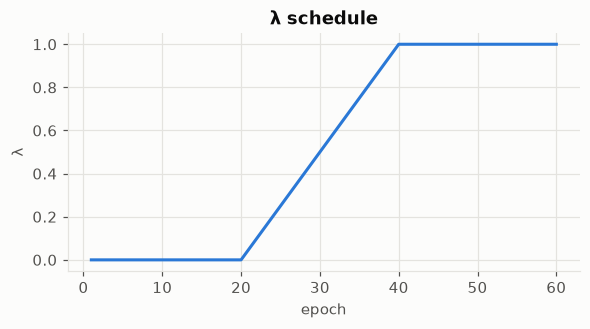

,run,encoder_grad_norm,decoder_grad_norm,classifier_params_received_grad,classifier_requires_grad,classifier_training_mode
0,Task-AE_d128_fold1_seed0,0.6265,53.5787,False,False,False
1,Task-AE_d128_fold2_seed0,1.6531,53.5753,False,False,False
2,Task-AE_d128_fold3_seed0,0.0795,3.1274,False,False,False
3,Task-AE_d128_fold4_seed0,0.2823,7.6080,False,False,False
4,Task-AE_d128_fold5_seed0,0.0912,17.0547,False,False,False
5,Task-AE_d128_fold6_seed0,0.7748,34.8717,False,False,False
6,Task-AE_d256_fold1_seed0,0.5462,27.9692,False,False,False
7,Task-AE_d256_fold2_seed0,1.5381,64.0227,False,False,False
8,Task-AE_d256_fold3_seed0,0.0368,2.5284,False,False,False
9,Task-AE_d256_fold4_seed0,0.3642,25.1285,False,False,False


In [2]:
ep = np.arange(1, 61)
fig, ax = plt.subplots(figsize=(6, 2.8)); ax.plot(ep, [lam_at(e, 'Task-AE', 1.0) for e in ep], color=SERIES[0])
ax.set(xlabel='epoch', ylabel='λ', title='λ schedule'); fig.savefig(FIG / 'lambda_schedule.png'); plt.show()
pd.DataFrame([dict(run=p.stem, **json.load(open(p))['gradient_check']) for p in sorted((LOGS / 'codecs').glob('Task-AE_d*_seed0.json'))])

## Learning curves d=128, seed 0

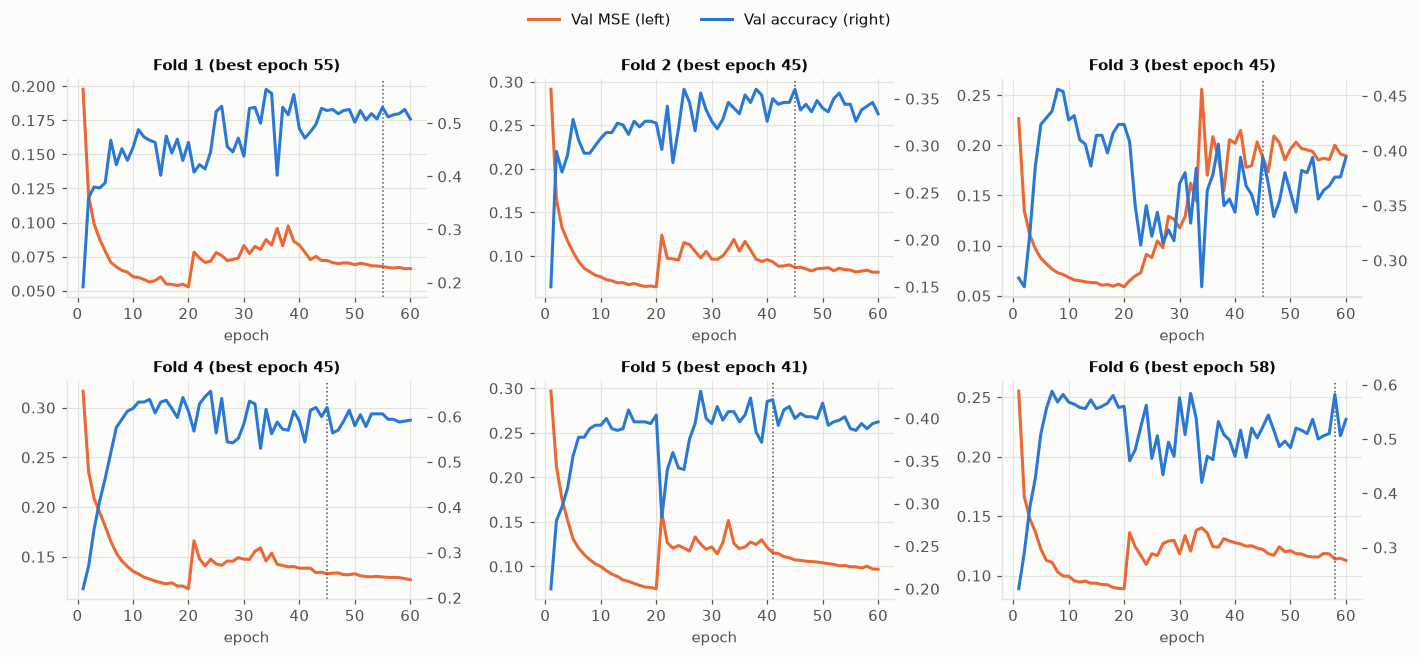

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, fold in zip(axes.ravel(), range(1, 7)):
    h = pd.read_csv(LOGS / 'codecs' / f'Task-AE_d128_fold{fold}_seed0_history.csv')
    ax.plot(h.epoch, h.val_mse, color=SERIES[1], label='Val MSE')
    ax2 = ax.twinx(); ax2.plot(h.epoch, h.val_acc, color=SERIES[0], label='Val accuracy'); ax2.grid(False)
    best = json.load(open(LOGS / 'codecs' / f'Task-AE_d128_fold{fold}_seed0.json'))['best_epoch']
    ax.axvline(best, color=TEXT2, ls=':', lw=1); ax.set_title(f'Fold {fold} (best epoch {best})', fontsize=10)
    ax.set_xlabel('epoch')
fig.legend(handles=[plt.Line2D([], [], color=SERIES[1]), plt.Line2D([], [], color=SERIES[0])],
           labels=['Val MSE (left)', 'Val accuracy (right)'], loc='upper center', ncol=2)
fig.tight_layout(rect=(0, 0, 1, 0.94)); fig.savefig(FIG / 'task_ae_learning_curves.png'); plt.show()

## Ví dụ tái tạo (fold 1, d=128, qua INT8 packet thật)

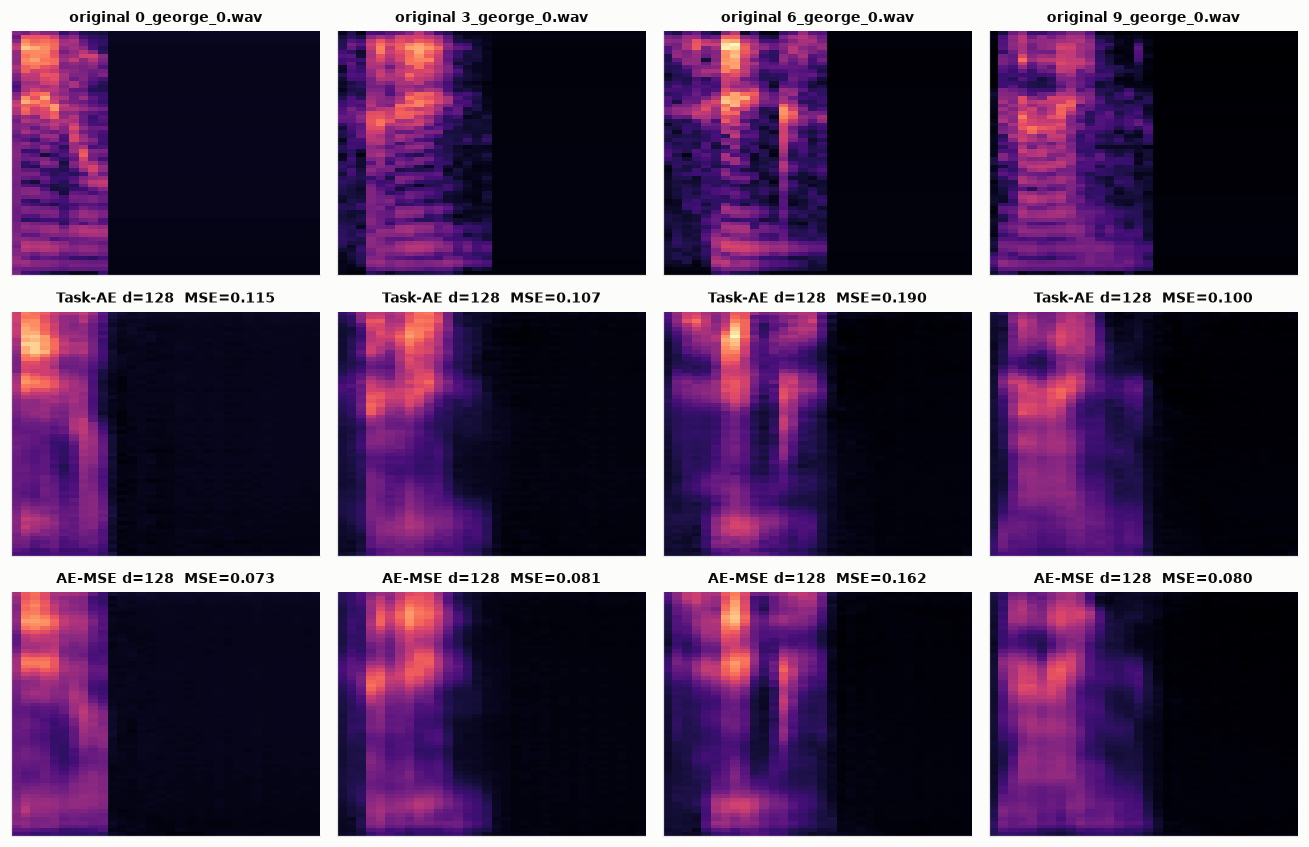

In [4]:
from evaluate import load_codec, codec_roundtrip
from dataset import load_fold
sp, mu, sigma = load_fold(1)
pick = [sp['test'].meta.index[sp['test'].meta.label == dg][0] for dg in (0, 3, 6, 9)]  # 4 different digits
x = sp['test'].x[pick]; names_f = sp['test'].meta.filename.iloc[pick].tolist()
vmin, vmax = x.min(), x.max()  # shared colour scale for all panels
names = ['Task-AE'] + (['AE-MSE'] if 'AE-MSE' else [])
fig, axes = plt.subplots(len(names) + 1, 4, figsize=(12, 2.6 * (len(names) + 1)))
for j in range(4):
    axes[0, j].imshow(x[j], origin='lower', aspect='auto', cmap='magma', vmin=vmin, vmax=vmax); axes[0, j].set_title(f'original {names_f[j]}', fontsize=9)
for i, n in enumerate(names, 1):
    xh = codec_roundtrip(load_codec(f'{n}_d128_fold1_seed0'), x, n)
    for j in range(4):
        axes[i, j].imshow(xh[j], origin='lower', aspect='auto', cmap='magma', vmin=vmin, vmax=vmax)
        axes[i, j].set_title(f'{n} d=128  MSE={((xh[j]-x[j])**2).mean():.3f}', fontsize=9)
for ax in axes.ravel(): ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); fig.savefig(FIG / 'task_ae_reconstructions.png'); plt.show()

## Kết quả Test

In [5]:
s = pd.read_csv(SUM / 'results_summary.csv')
r = s[s.method.isin(['Task-AE', 'Original'] + (['AE-MSE'] if 'AE-MSE' else []))]
display(r[r.seed == 0].pivot_table(index=['method', 'd'], columns='test_speaker', values='Accuracy'))
r.groupby(['method', 'd', 'seed'])[['Accuracy', 'Macro_F1', 'Delta_A_pp', 'R_acc', 'MSE', 'PRD_spec']].mean()

test_speaker   george  jackson  lucas  nicolas   theo  yweweler
method   d                                                     
AE-MSE   64    0.4120   0.4620 0.1660   0.2200 0.4300    0.3780
         128   0.5140   0.5100 0.2000   0.2700 0.4660    0.4640
         256   0.5120   0.5420 0.2240   0.2440 0.4660    0.5040
Original 2048  0.5140   0.5620 0.2400   0.2700 0.4380    0.5160
Task-AE  64    0.4100   0.6480 0.2720   0.2940 0.4460    0.5180
         128   0.4720   0.5960 0.2100   0.2860 0.4840    0.5160
         256   0.5280   0.6200 0.2600   0.2840 0.4620    0.5180

Accuracy  Macro_F1  Delta_A_pp    R_acc    MSE  PRD_spec
method   d    seed                                                          
AE-MSE   64   0       0.3447    0.2925     -7.8667  80.7399 0.1064   29.5218
         128  0       0.4040    0.3589     -1.9333  95.0660 0.0679   23.8243
              1       0.4197    0.3818     -2.5333  95.4215 0.0680   23.9621
              2       0.4413    0.3952     -1.6000  96.7511 0.0695   24.1315
         256  0       0.4153    0.3683     -0.8000  97.3038 0.0469   20.0525
Original 2048 0       0.4233    0.3732      0.0000 100.0000 0.0000    0.0000
              1       0.4450    0.4056      0.0000 100.0000 0.0000    0.0000
              2       0.4573    0.4123      0.0000 100.0000 0.0000    0.0000
Task-AE  64   0       0.4313    0.3877      0.8000 103.2509 0.1728   38.0325
         128  0       0.4273    0.3878      0.4000 100.3011 0.1236   31.8661
              1       0.4503    0.4143      0.5333 102.7055 0.0899   27.5881
              2       0.4633    0.4214      0.6000 101.6357 0.1006   29.2725
         256  0       0.4453    0.4060      2.2000 105.4049 0.1108   30.6890